In [1]:
import sys
sys.path.append("..")  # Adds the parent directory to the path
from utilities.correlations import *
from utilities.explanation import *
from utilities.for_ploting import *
from utilities.feature_engineering import *
from utilities.imputation import *
from utilities.modelling import *
from utilities.preprocessing import *
from utilities.cleaning import *

pd.set_option('display.max_columns', None)

# Optional: also show full width for each column
pd.set_option('display.expand_frame_repr', False)


Generating 2D Scatter Plot with Color Encoding...


In [2]:
df = pd.read_csv('bank-full.csv', sep=';', encoding="ISO-8859-1")

# EDA

In [3]:
display_basic_info(df)


 Number of Rows and Columns:
 (45211, 17)

Data Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB

Number of Unique Values:
 age            7

--- Plotting Numerical Features vs Target ('y') ---


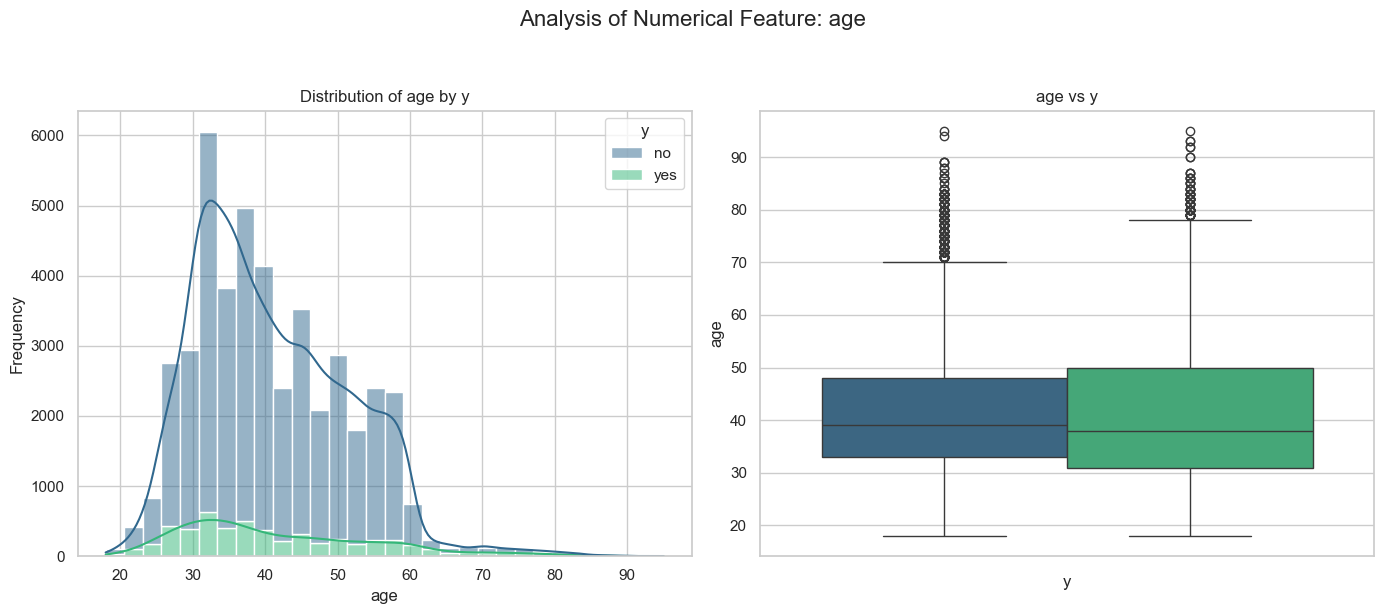

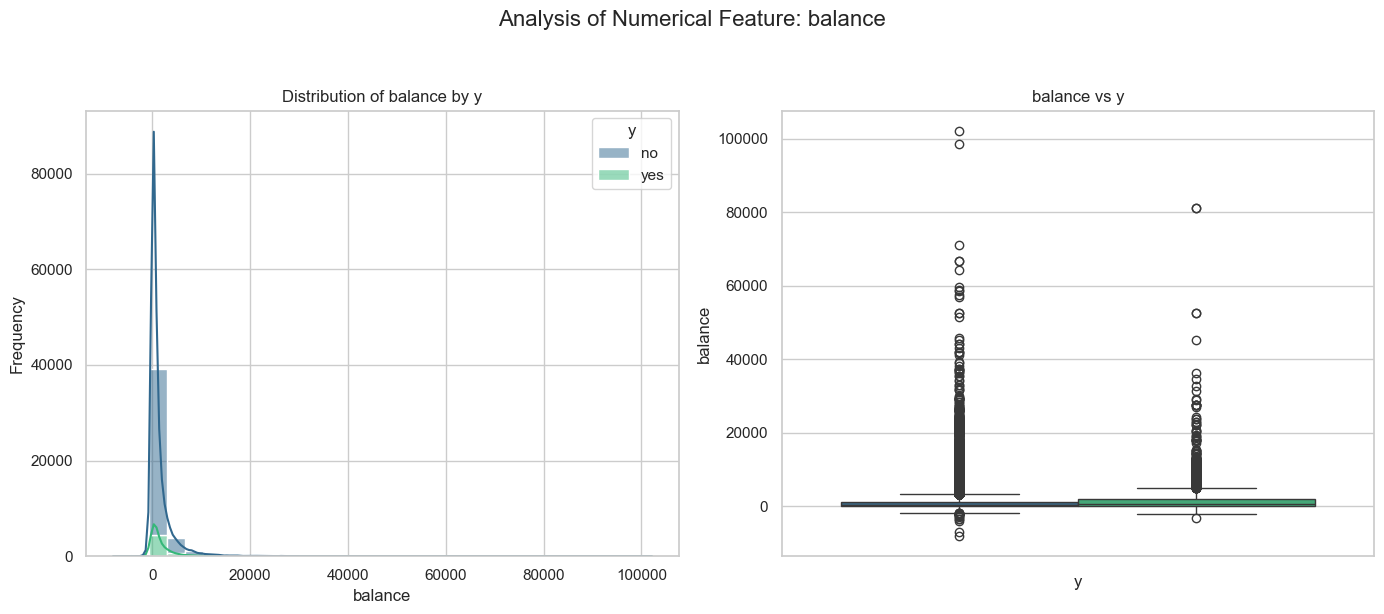

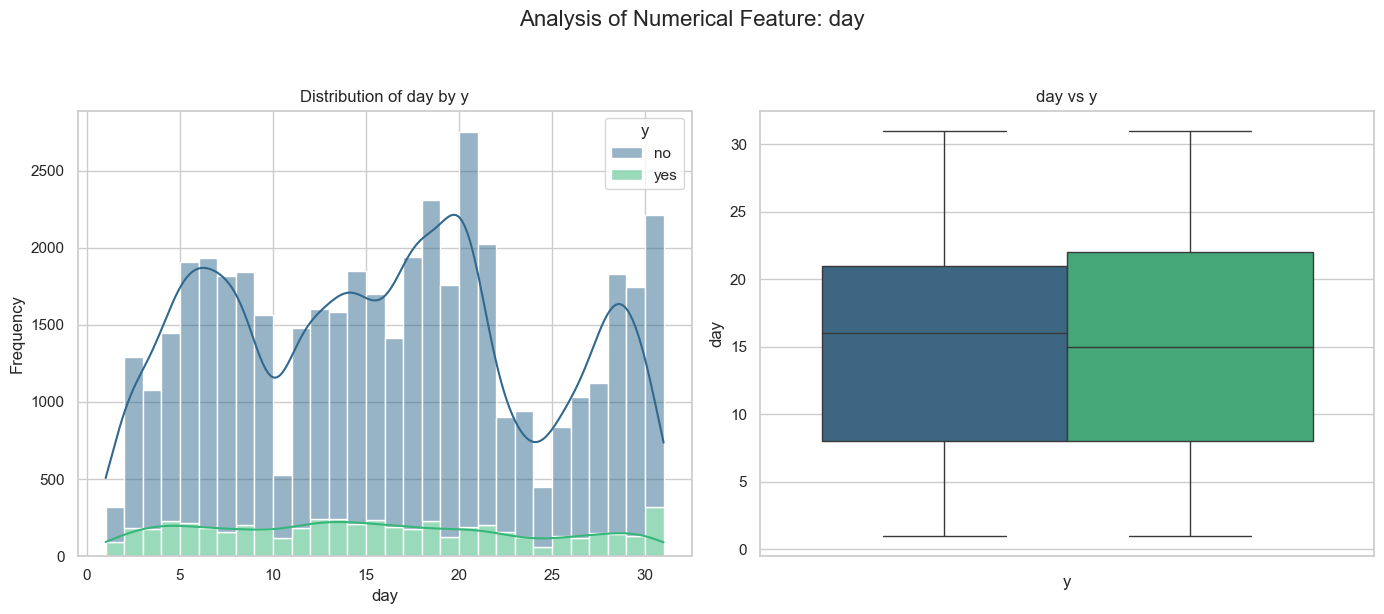

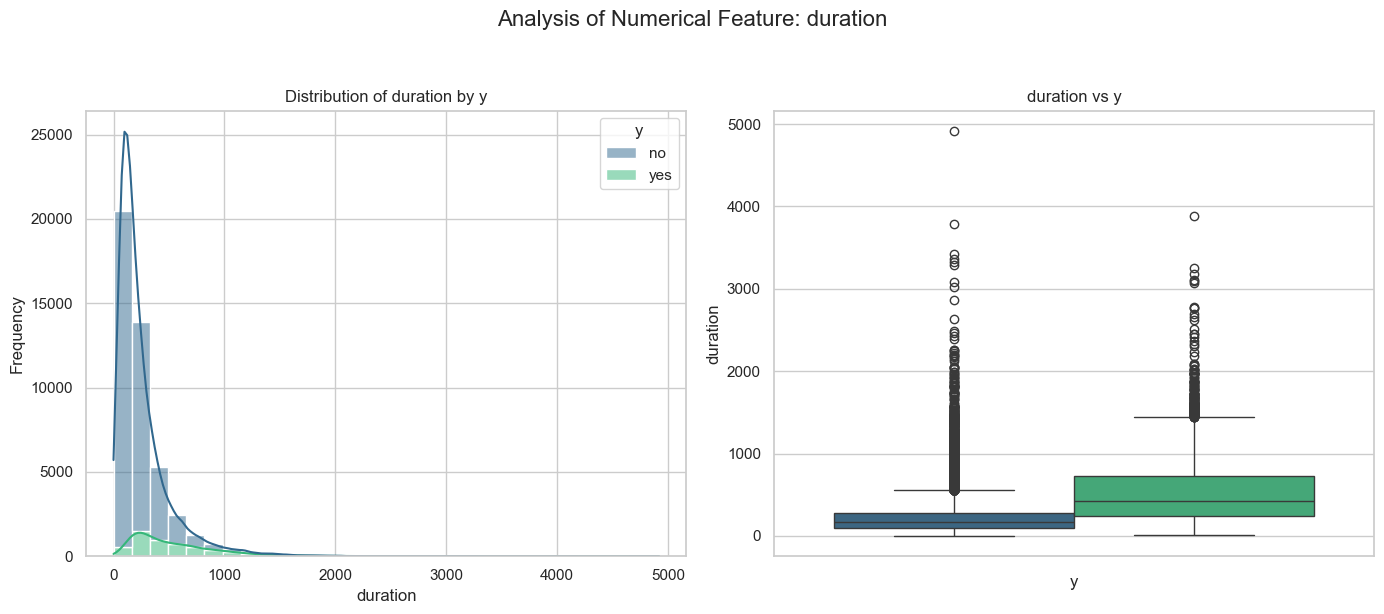

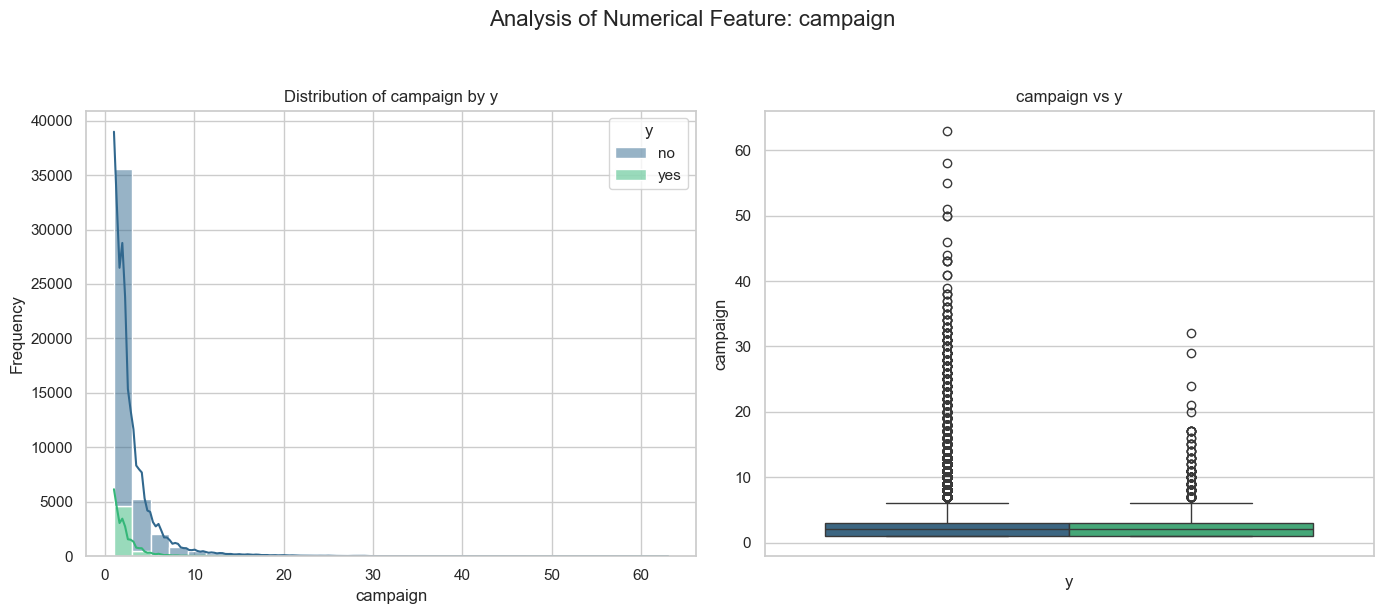

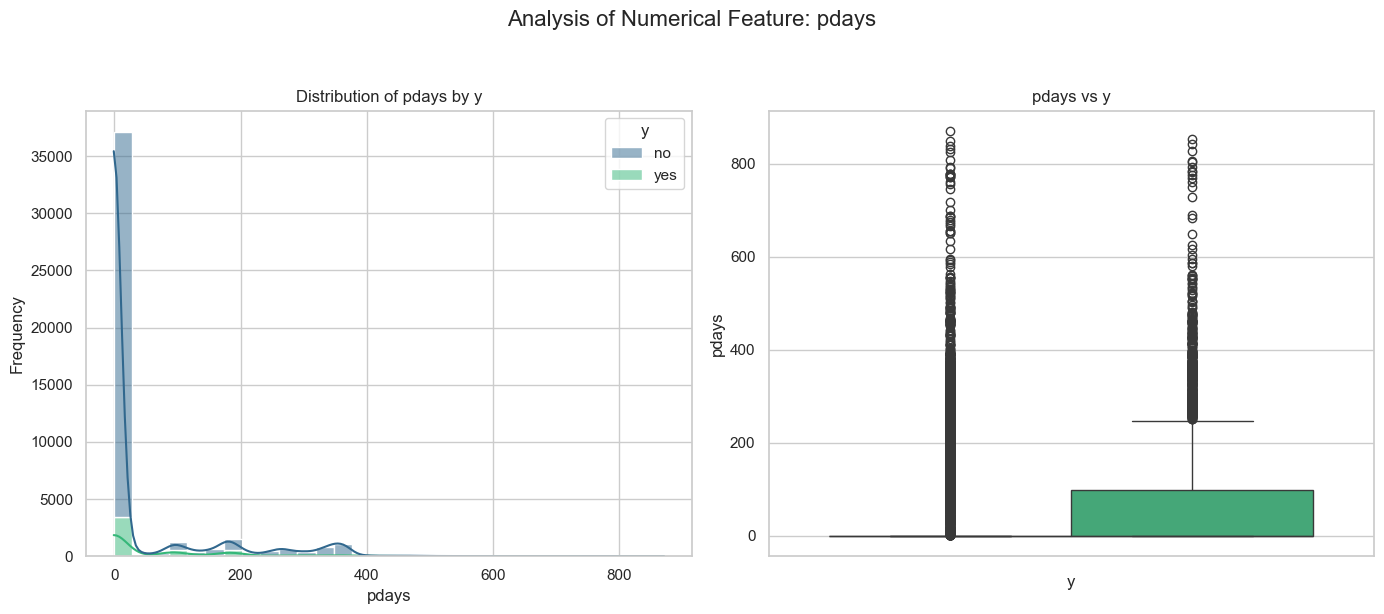

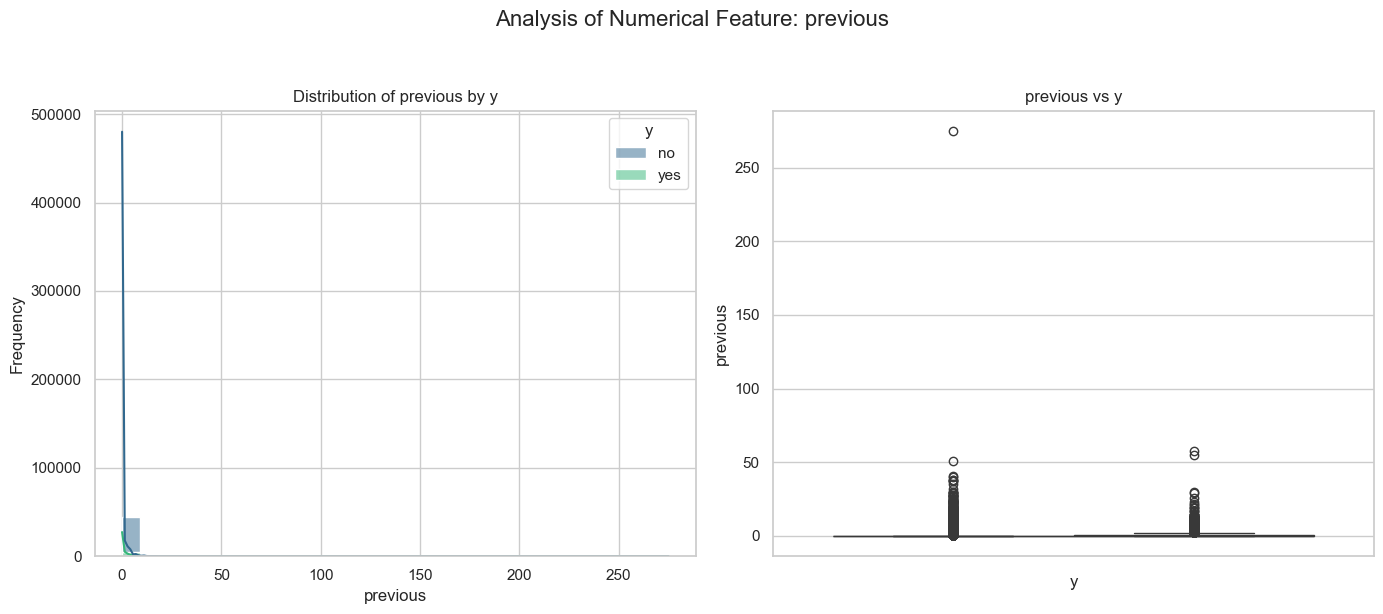

In [4]:
plot_all_num_vs_target(df, 'y')

--- Plotting Categorical Features vs Target ('y') ---


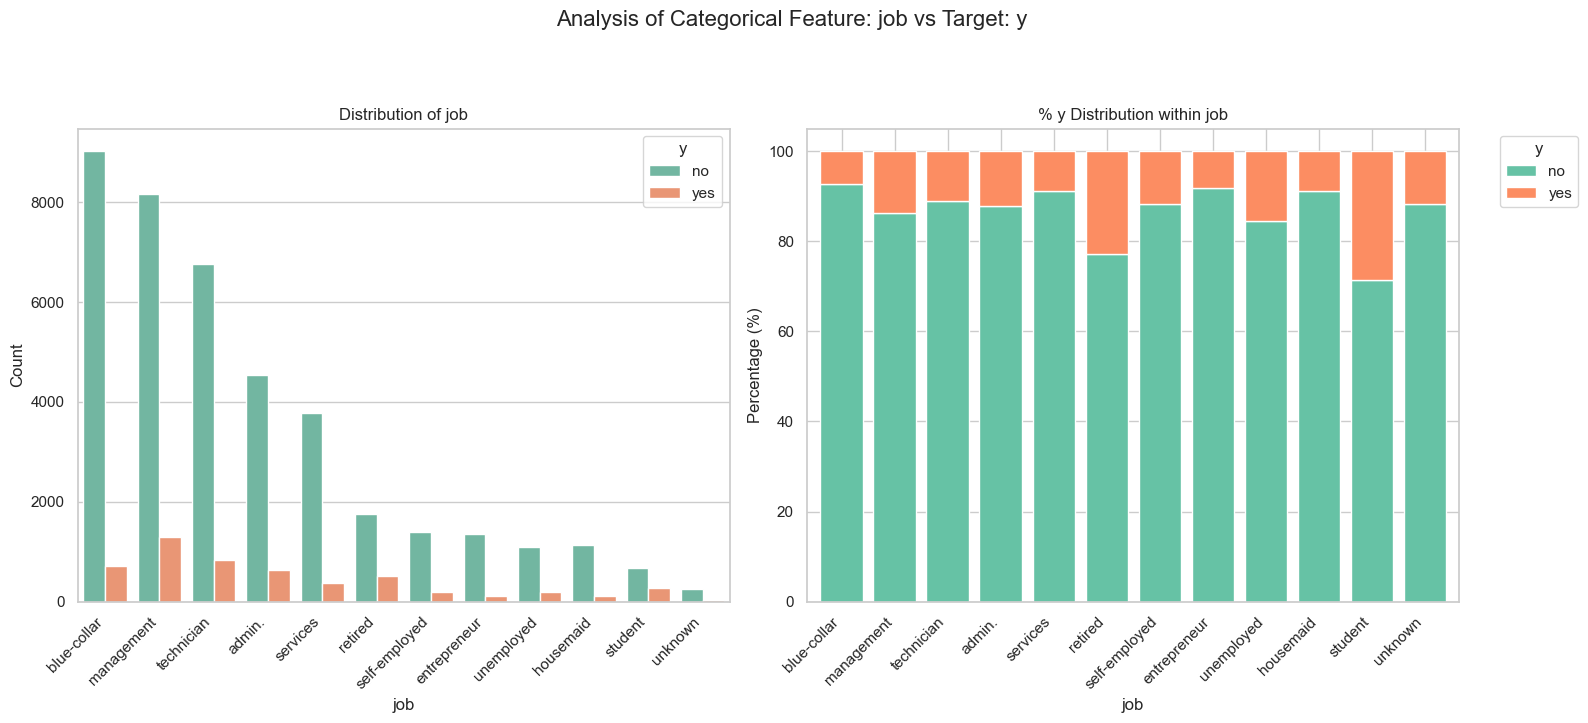

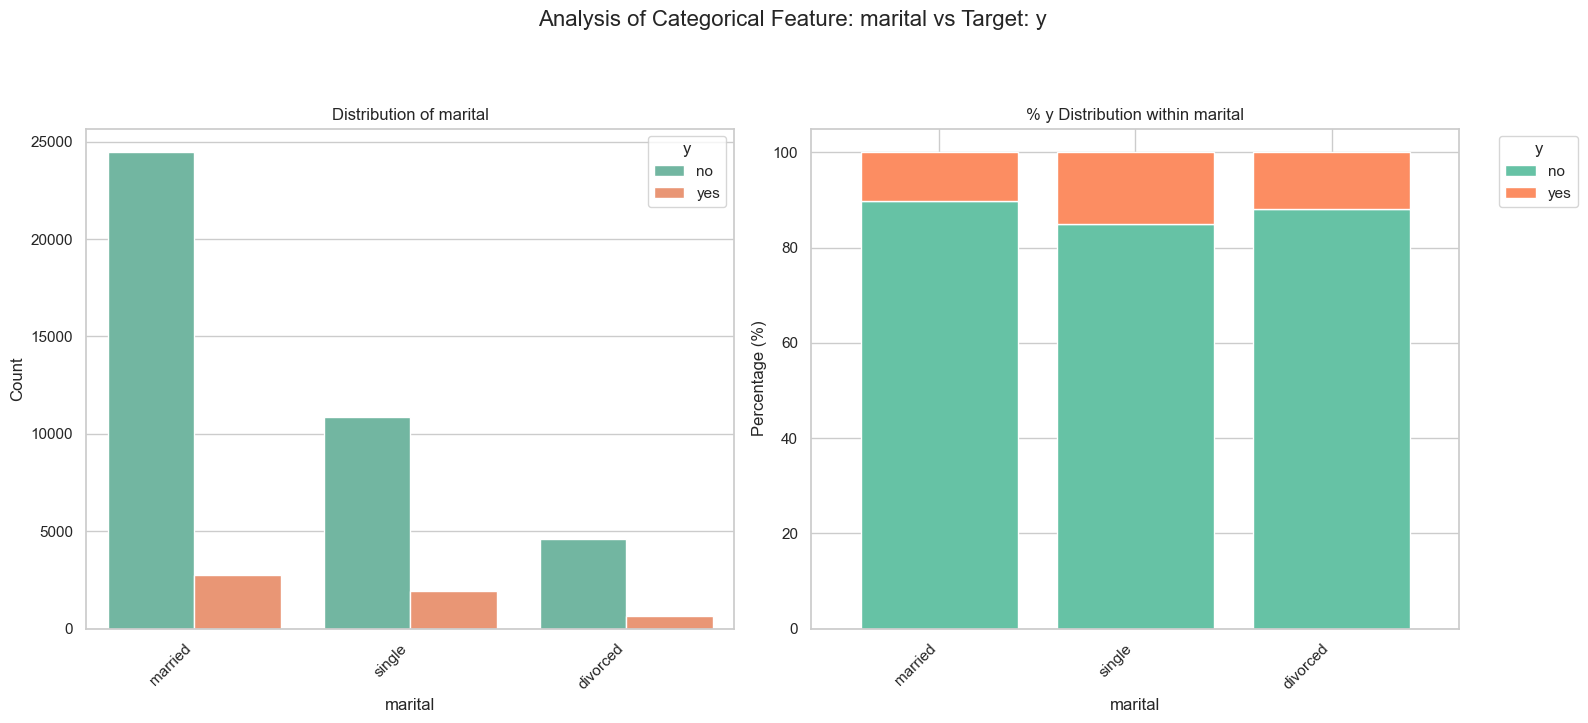

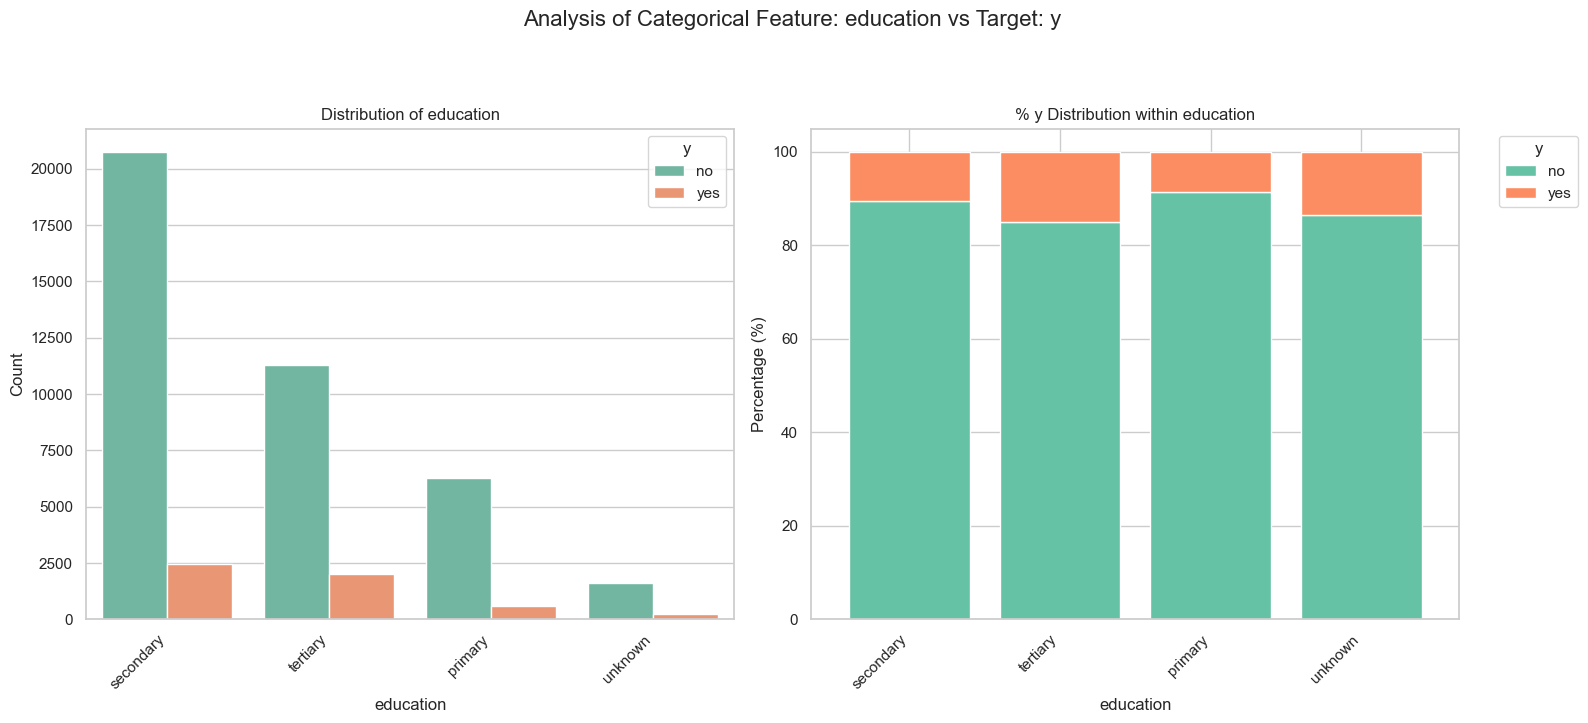

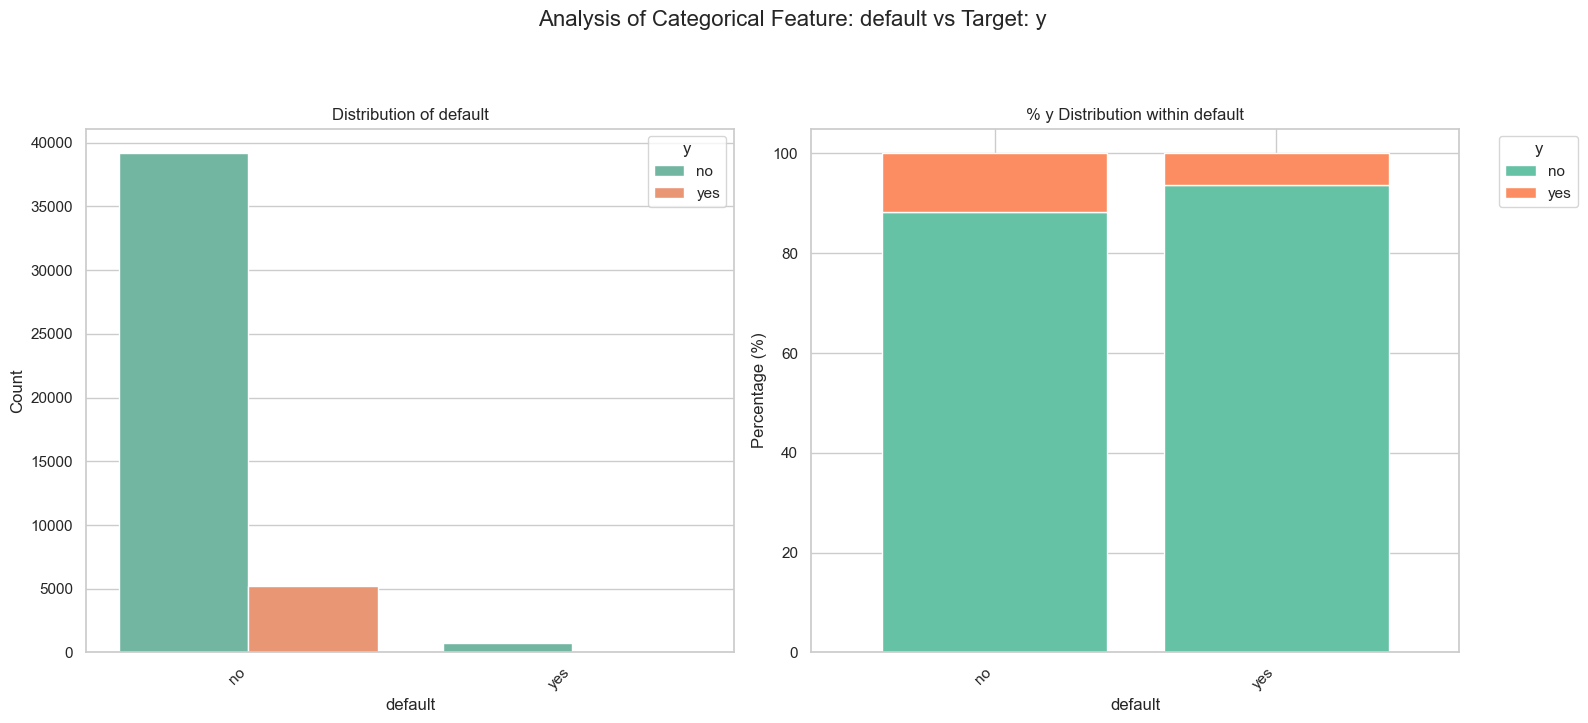

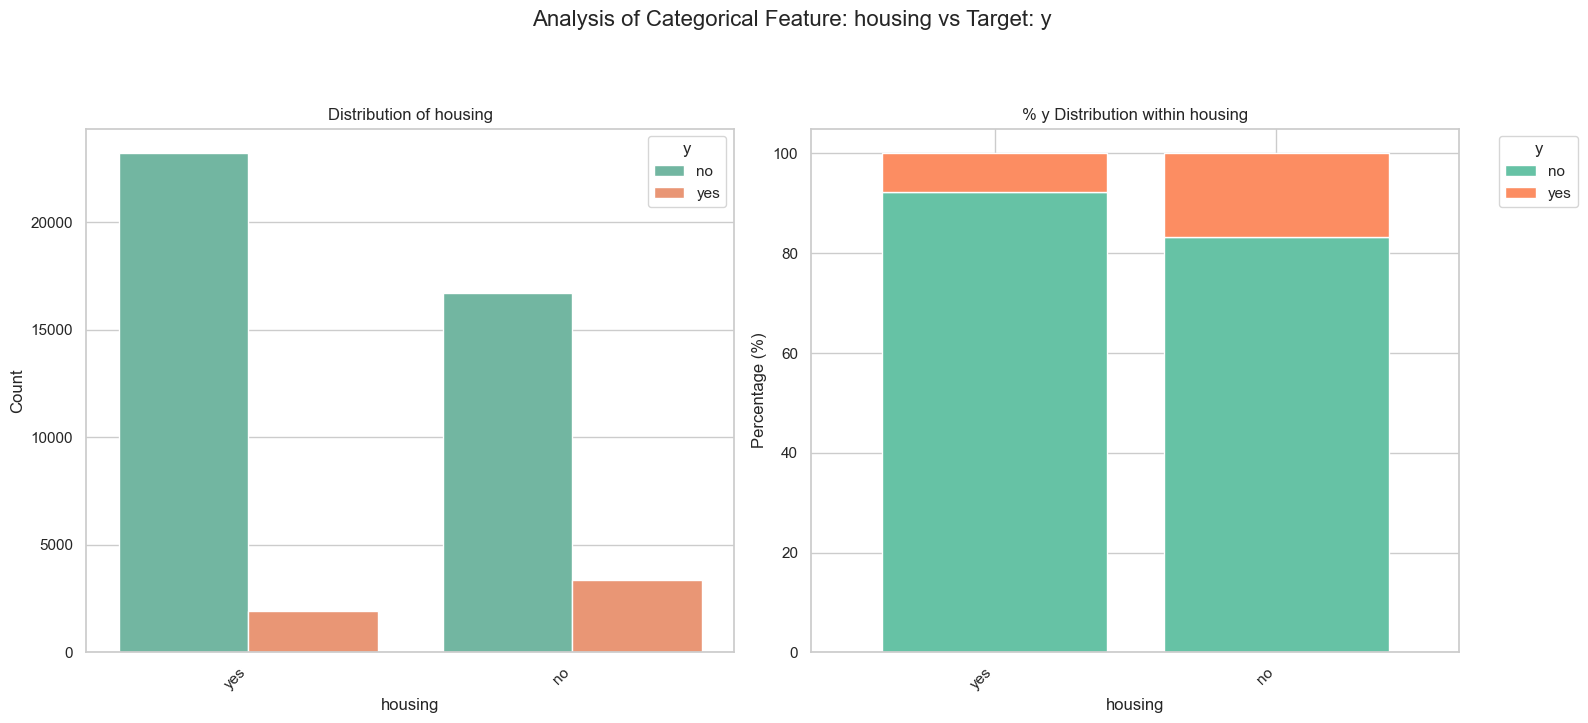

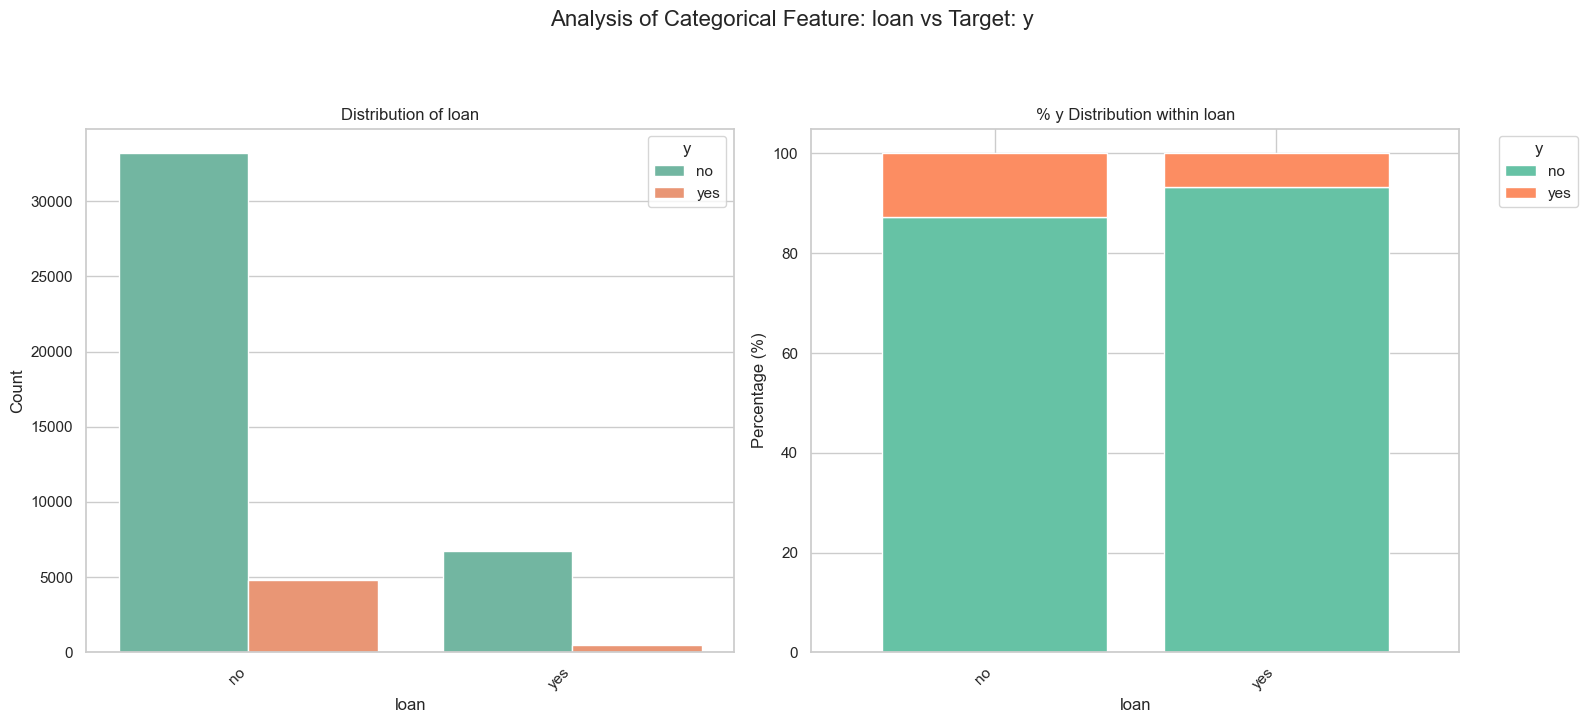

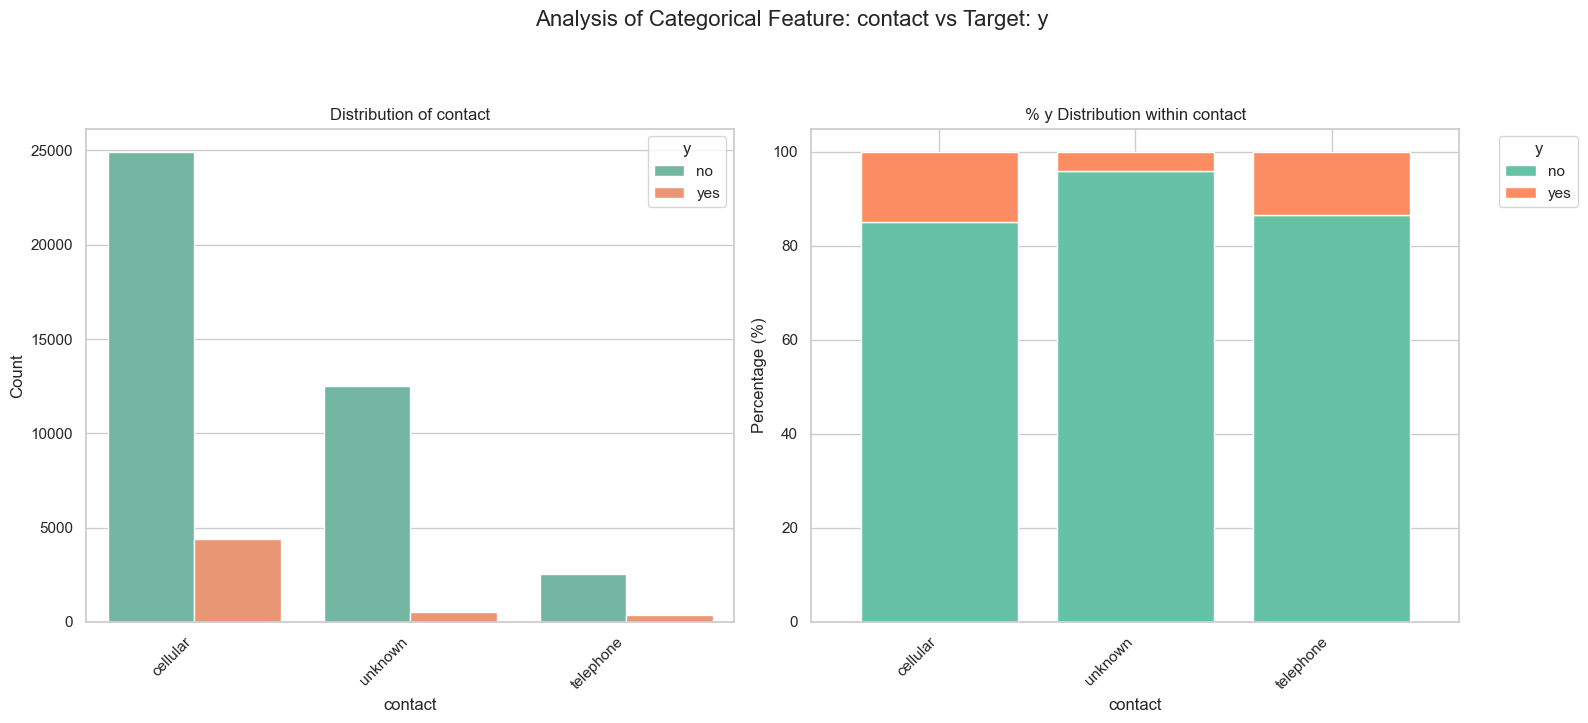

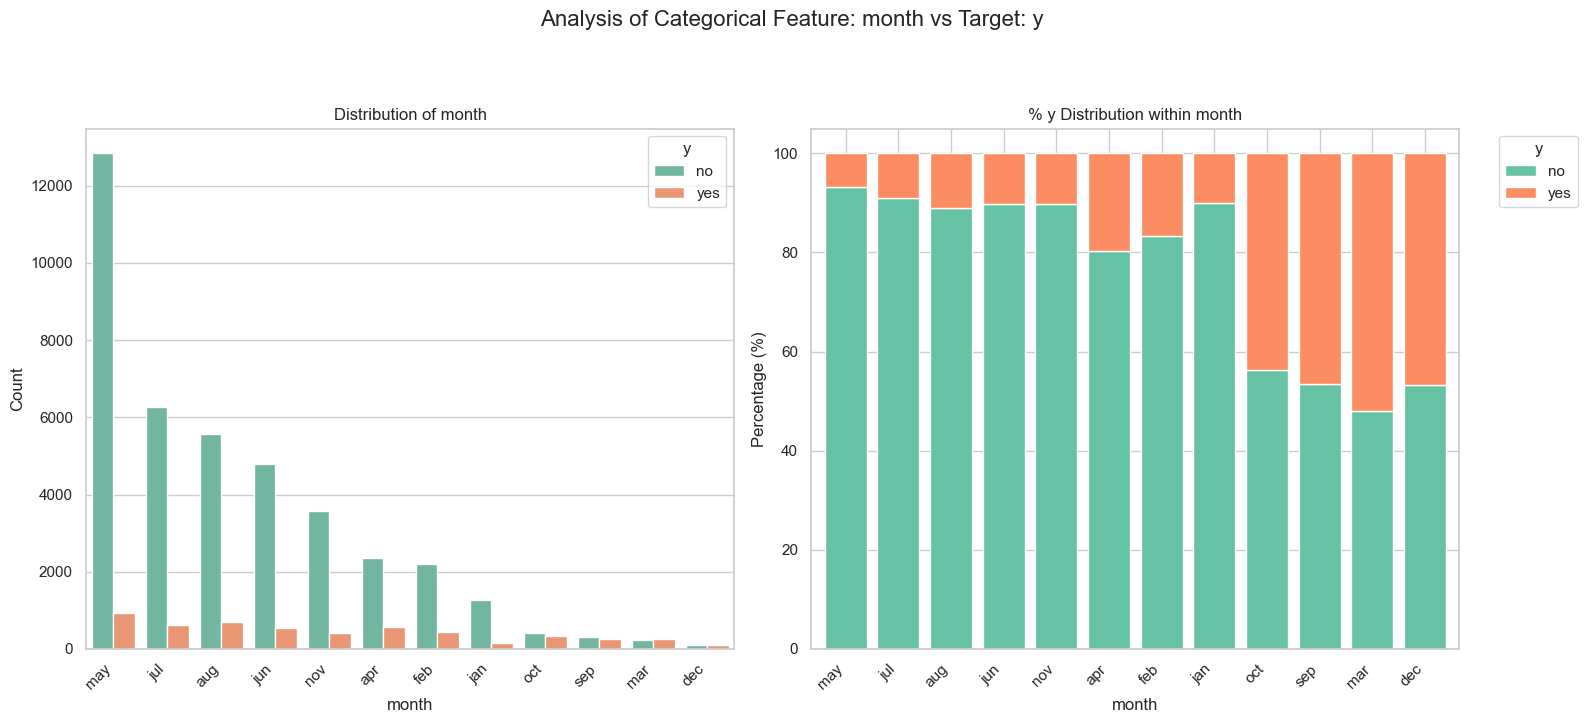

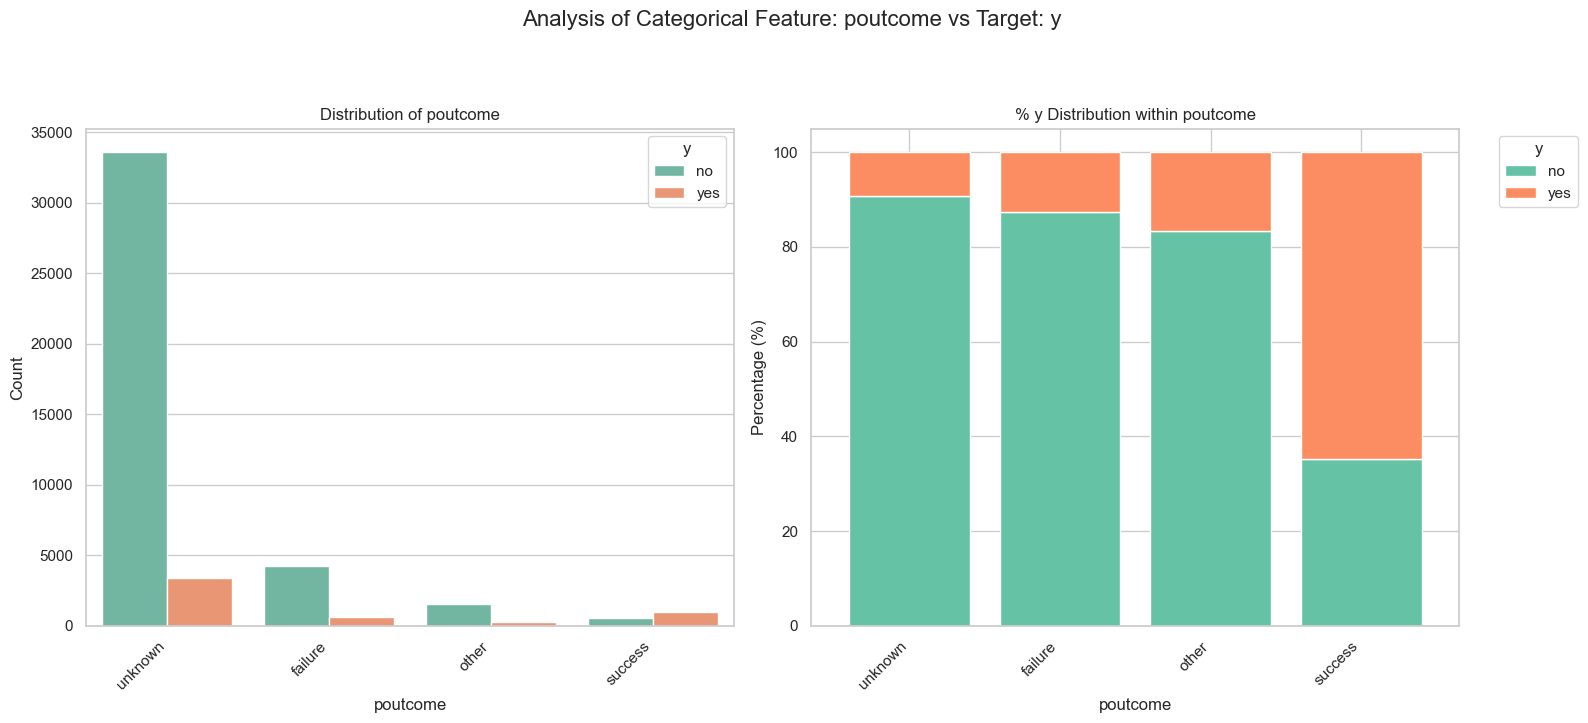

In [5]:
plot_all_cat_vs_target(df, 'y')

In [6]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Feature Engineering

In [7]:
# 1. 'pdays' Transformation
#    -1 means client was not previously contacted.
#    Create a binary flag for whether they were contacted.
#    Keep 'pdays' as a numerical feature; LightGBM can find a split point for -1 vs other values.
df['was_contacted_previously'] = (df['pdays'] != -1).astype(int)

# 2. Numerical Feature Transformations (Log for Skewness, Special Handling)

# 'balance'
# Flag for negative balance
df['has_negative_balance'] = (df['balance'] < 0).astype(int)
# Log transform balance. To handle non-positive values for log, we can:
# Method A: Shift all values to be > 0 then log1p.
# This preserves relative differences but shifts the scale.
min_balance = df['balance'].min()
if min_balance <= 0:
    df['balance_log_shifted'] = np.log1p(df['balance'] - min_balance)
else: # If all balances are already positive
    df['balance_log_shifted'] = np.log1p(df['balance'])
# Original 'balance' is kept for now, can decide to drop later if log version is better.

# 'duration'
# Duration is usually > 0. log1p is safe.
# As noted before, 'duration' can be a leakage feature if predicting *who to call*.
# If used, a log transform is common.
df['duration_log'] = np.log1p(df['duration'])

# 'campaign' (number of contacts during this campaign)
df['campaign_log'] = np.log1p(df['campaign'])

# 'previous' (number of contacts before this campaign)
df['previous_log'] = np.log1p(df['previous'])


# 3. Date-Related Features: 'month' to 'season'
# The original 'month' column will be kept as it provides finer granularity.
month_to_season_map = {
    'jan': 'Winter', 'feb': 'Winter', 'mar': 'Spring',
    'apr': 'Spring', 'may': 'Spring', 'jun': 'Summer',
    'jul': 'Summer', 'aug': 'Summer', 'sep': 'Autumn',
    'oct': 'Autumn', 'nov': 'Autumn', 'dec': 'Winter'
}
df['season'] = df['month'].map(month_to_season_map)

# Training and Evaluation

In [8]:
x = df.drop(columns=['y'],axis=1)
y = df['y'].map({'no':0,'yes':1})

In [9]:
cat_cols = x.select_dtypes(include='object').columns.to_list()
for col in cat_cols:
    x[col] = x[col].astype('category')

In [10]:
from sklearn.model_selection import train_test_split,cross_val_score
from lightgbm import LGBMClassifier

In [11]:
acc, std = cross_val_model_auto(df,'y')
print(f"Accuracy: {100*acc:.2f}% STD: {std:.2f}")

scores: [0.90688931 0.90389294 0.90433532 0.90721079 0.9093121 ]
Accuracy: 90.63% STD: 0.00


In [12]:
train_x,test_x,train_y,test_y = train_test_split(x,y,test_size=0.2)

Class unbalanced: True
[1]	valid_0's auc: 0.90373	valid_0's binary_logloss: 0.316405
Training until validation scores don't improve for 100 rounds
[2]	valid_0's auc: 0.913906	valid_0's binary_logloss: 0.297712
[3]	valid_0's auc: 0.917493	valid_0's binary_logloss: 0.28764
[4]	valid_0's auc: 0.922095	valid_0's binary_logloss: 0.281701
[5]	valid_0's auc: 0.923893	valid_0's binary_logloss: 0.279229
[6]	valid_0's auc: 0.925182	valid_0's binary_logloss: 0.27762
[7]	valid_0's auc: 0.927279	valid_0's binary_logloss: 0.276321
[8]	valid_0's auc: 0.928599	valid_0's binary_logloss: 0.277199
[9]	valid_0's auc: 0.929627	valid_0's binary_logloss: 0.277607
[10]	valid_0's auc: 0.930276	valid_0's binary_logloss: 0.278937
[11]	valid_0's auc: 0.931485	valid_0's binary_logloss: 0.280484
[12]	valid_0's auc: 0.932047	valid_0's binary_logloss: 0.282354
[13]	valid_0's auc: 0.932703	valid_0's binary_logloss: 0.284363
[14]	valid_0's auc: 0.933437	valid_0's binary_logloss: 0.286512
[15]	valid_0's auc: 0.933414	va

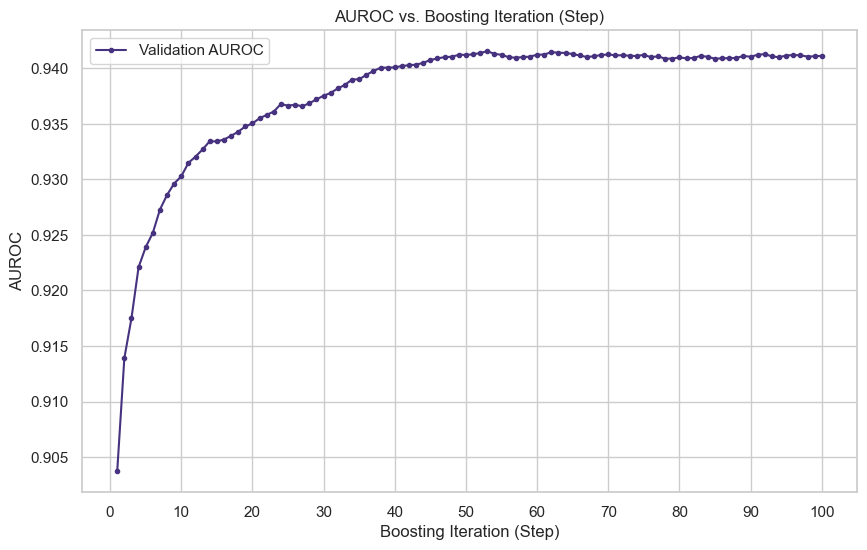


Best Iteration (based on validation AUROC): 53
Best Validation AUROC: 0.9415


In [13]:
model = training_binary_classification_with_lgbm(train_x,train_y,split=0.1)


--- Evaluating LGBMClassifier ---
Accuracy: 0.8500
Precision: 0.4271
Recall: 0.8941
F1 Score: 0.5781
AUC-ROC: 0.9346

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.84      0.91      8004
           1       0.43      0.89      0.58      1039

    accuracy                           0.85      9043
   macro avg       0.71      0.87      0.74      9043
weighted avg       0.92      0.85      0.87      9043



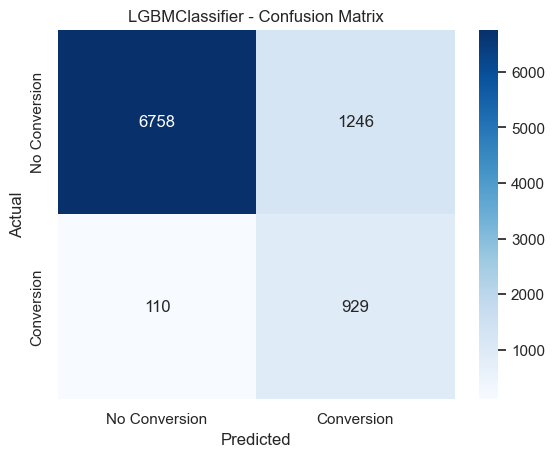

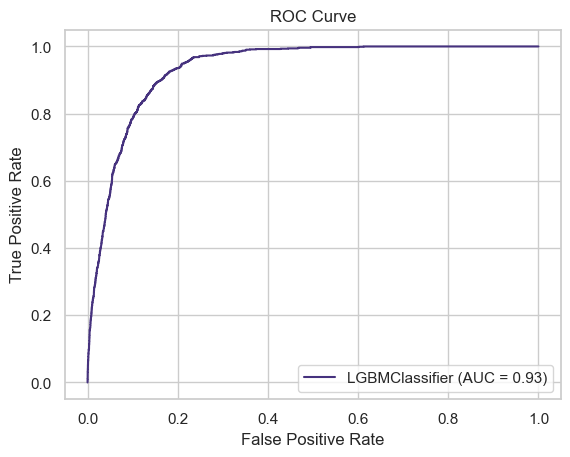

In [14]:
evaluate_binary_classification_model(model, 'LGBMClassifier', test_x, test_y)

# Explanation

C:\Users\qli97\AppData\Roaming\Python\Python312\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


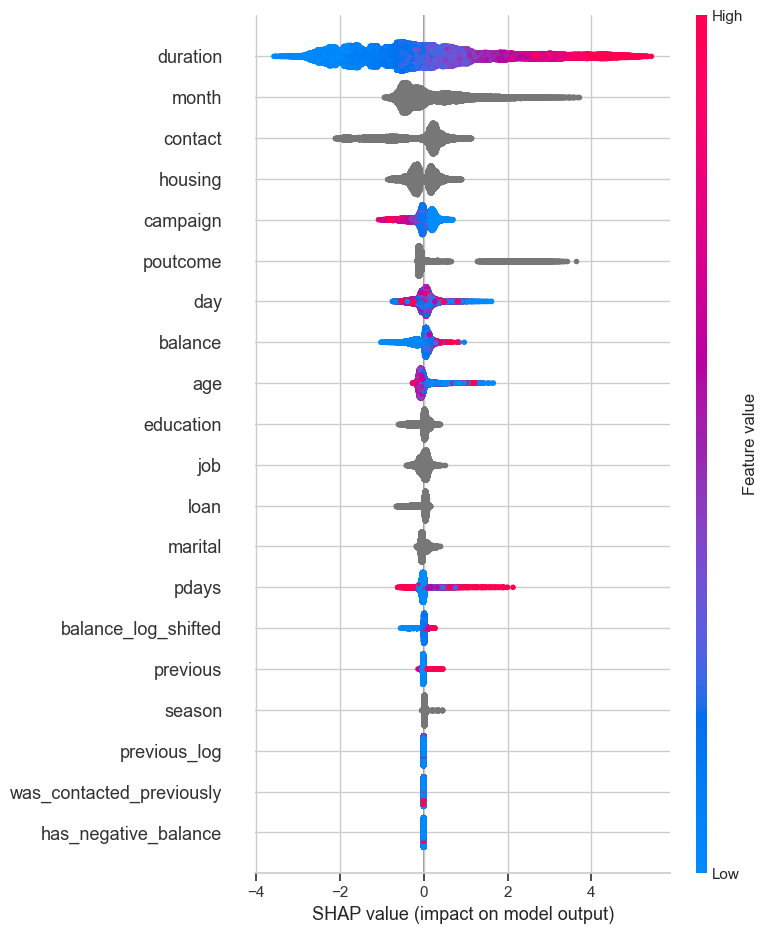

<Figure size 1400x800 with 0 Axes>

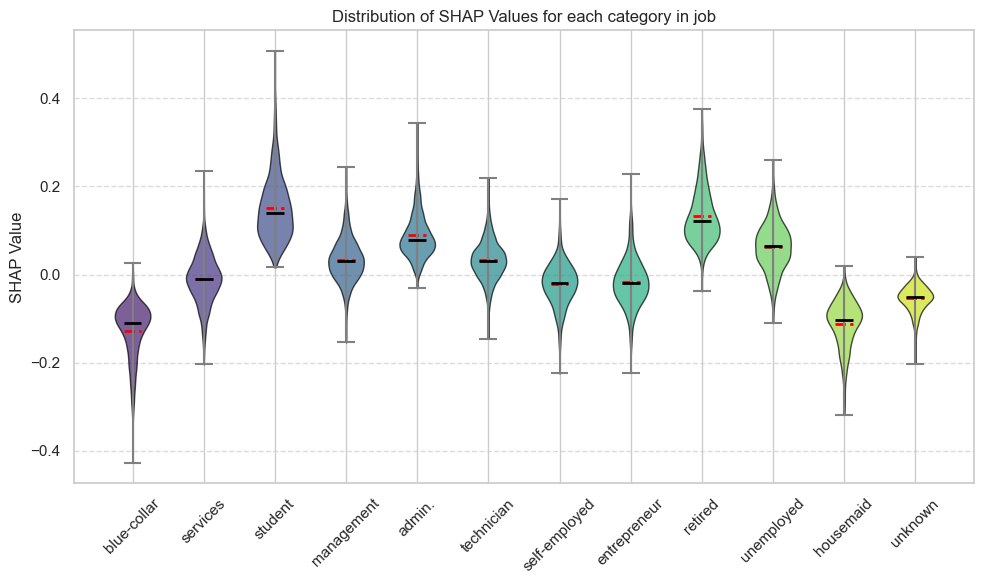

<Figure size 1400x800 with 0 Axes>

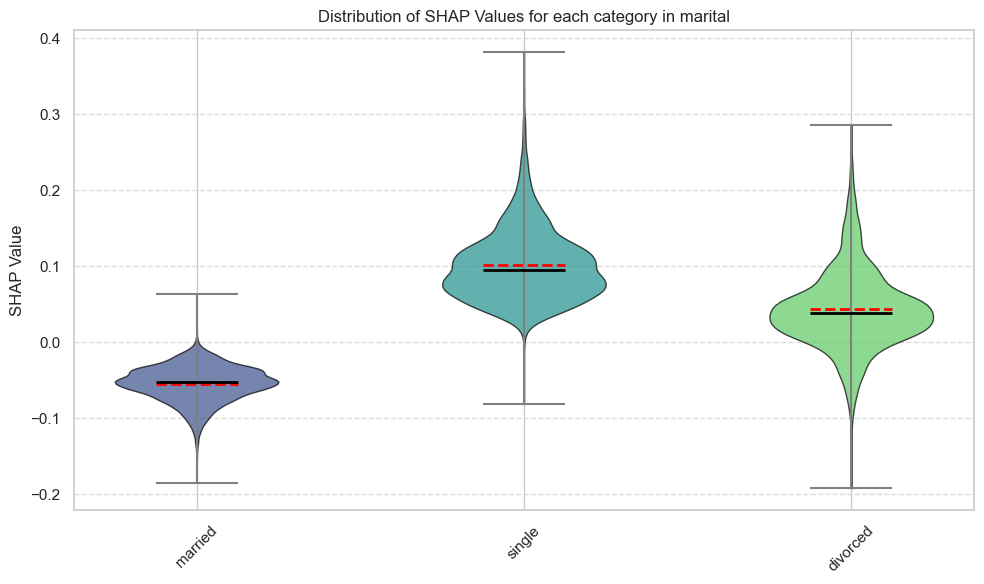

<Figure size 1400x800 with 0 Axes>

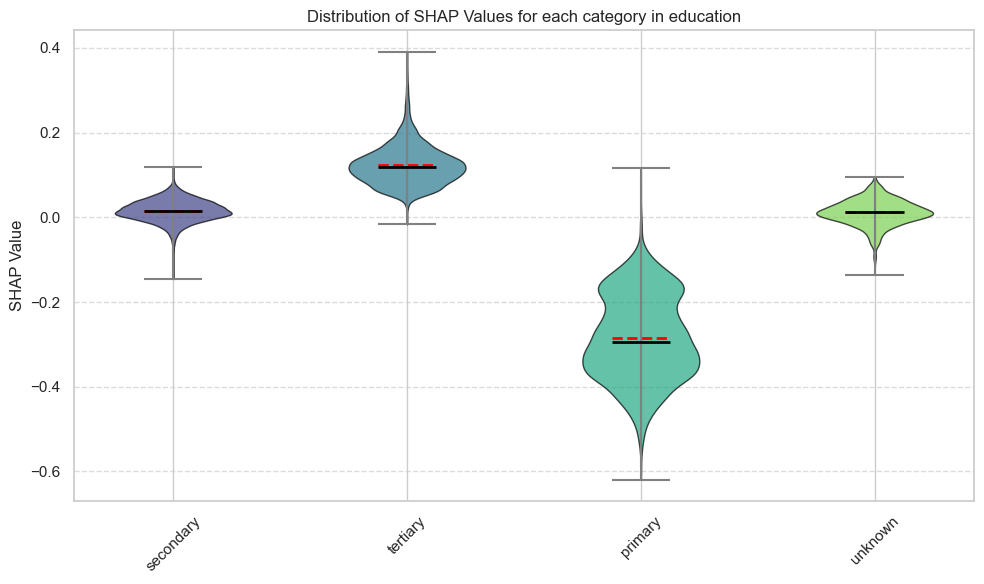

<Figure size 1400x800 with 0 Axes>

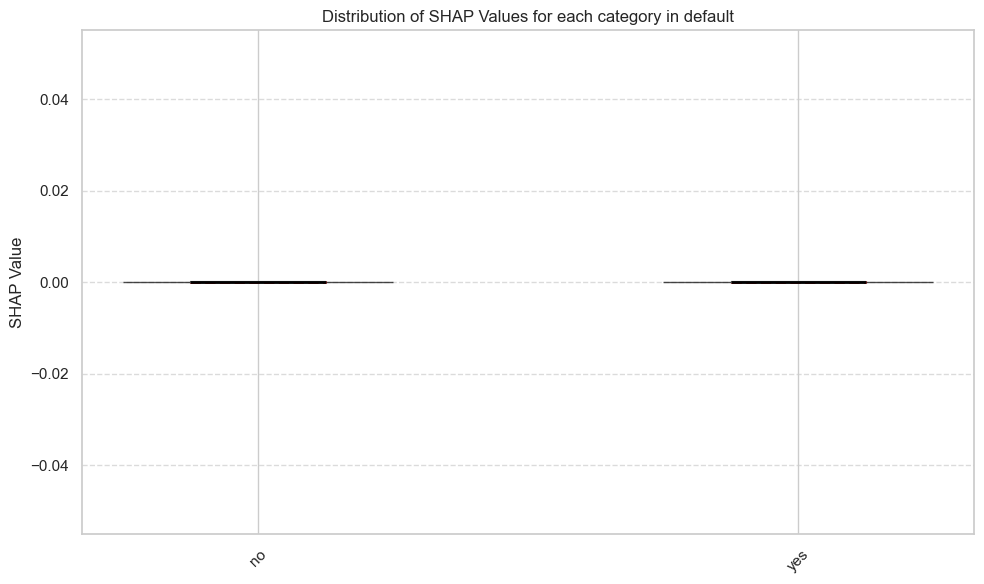

<Figure size 1400x800 with 0 Axes>

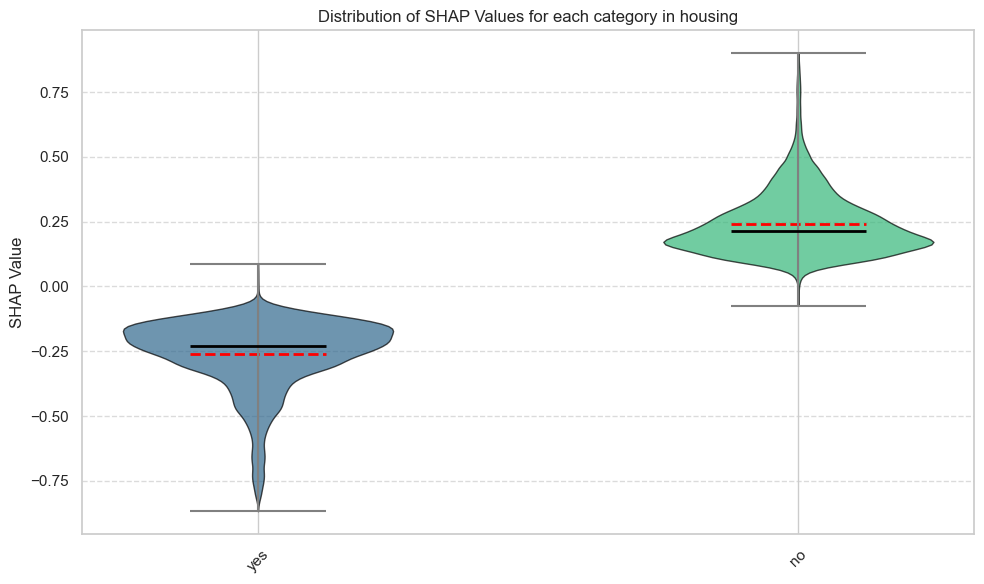

<Figure size 1400x800 with 0 Axes>

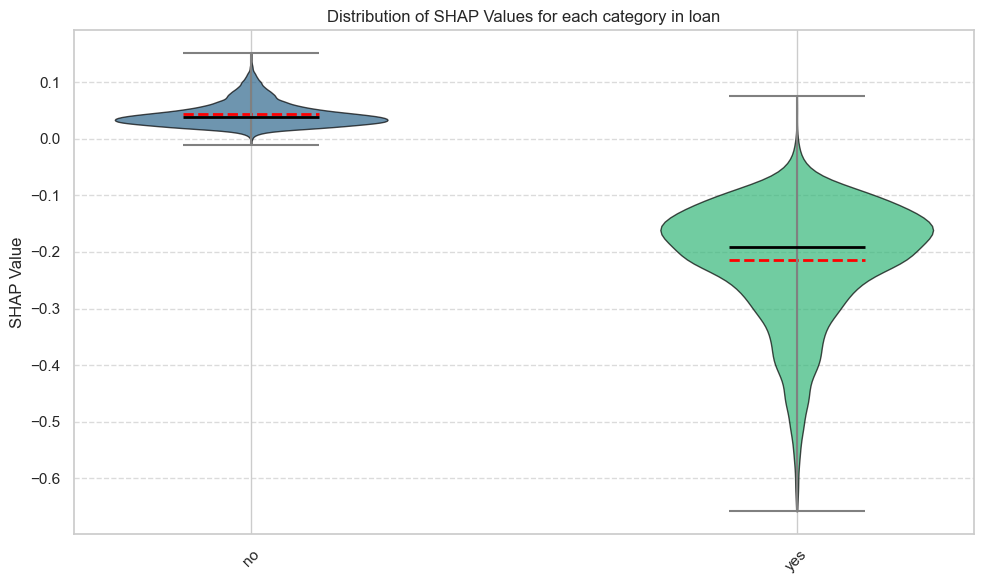

<Figure size 1400x800 with 0 Axes>

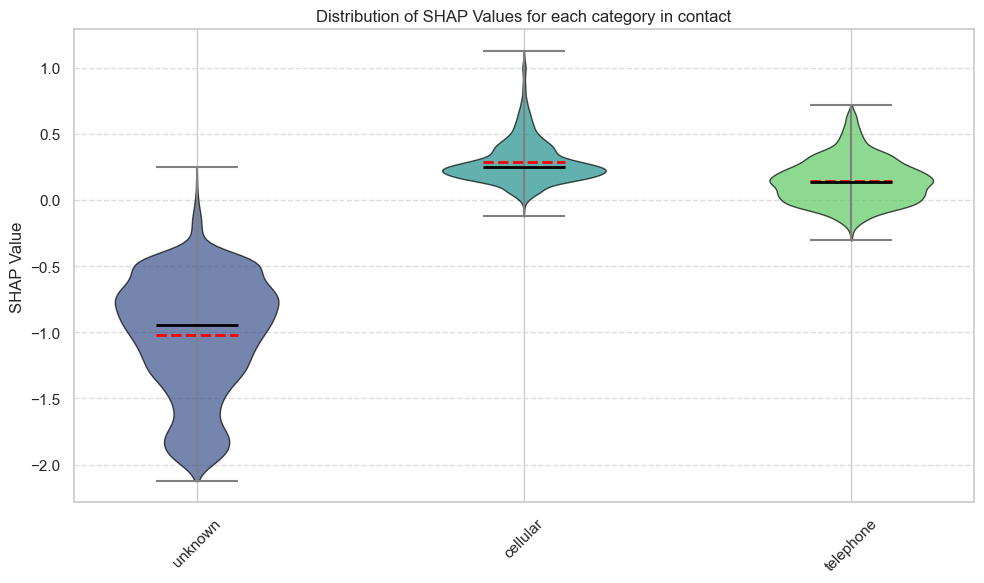

<Figure size 1400x800 with 0 Axes>

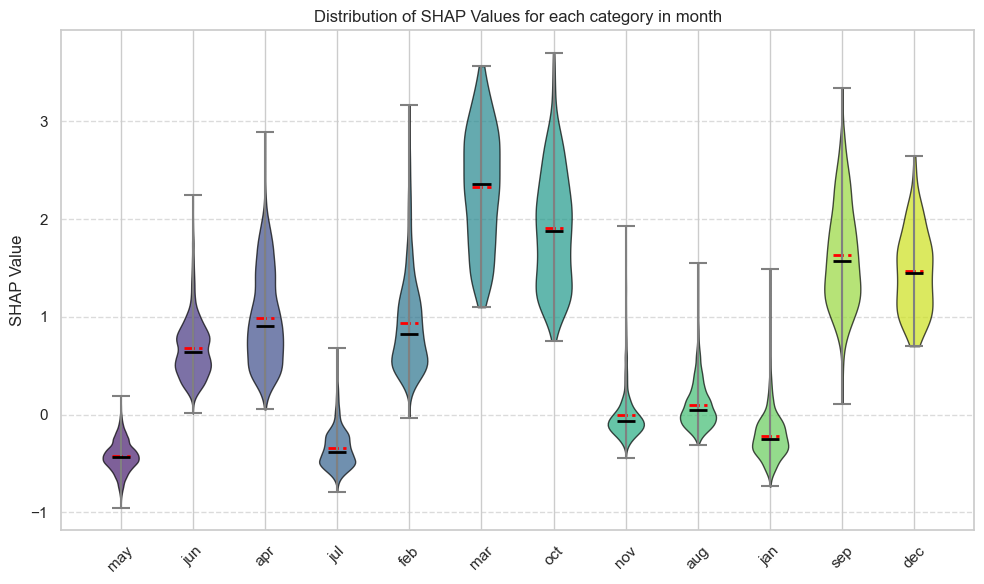

<Figure size 1400x800 with 0 Axes>

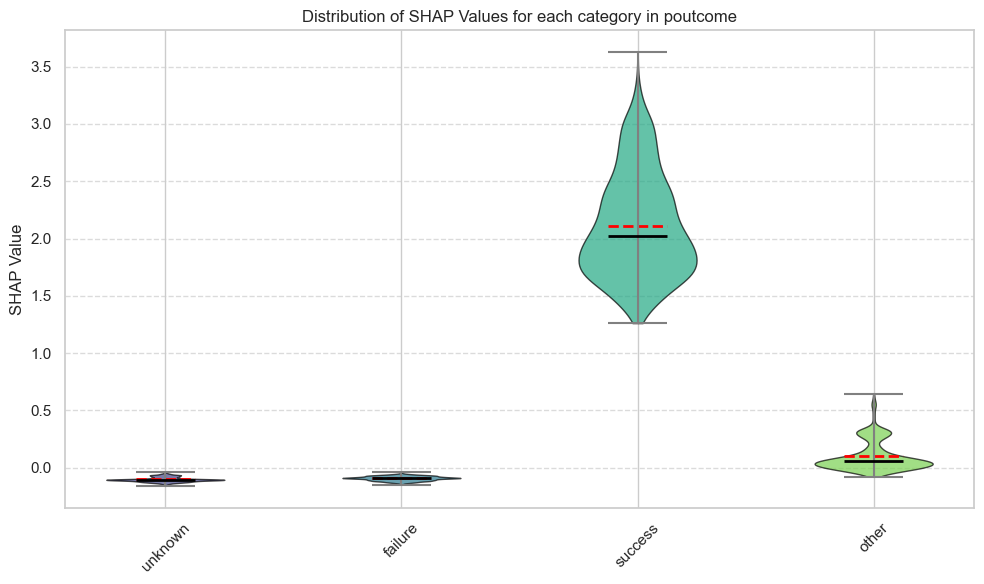

<Figure size 1400x800 with 0 Axes>

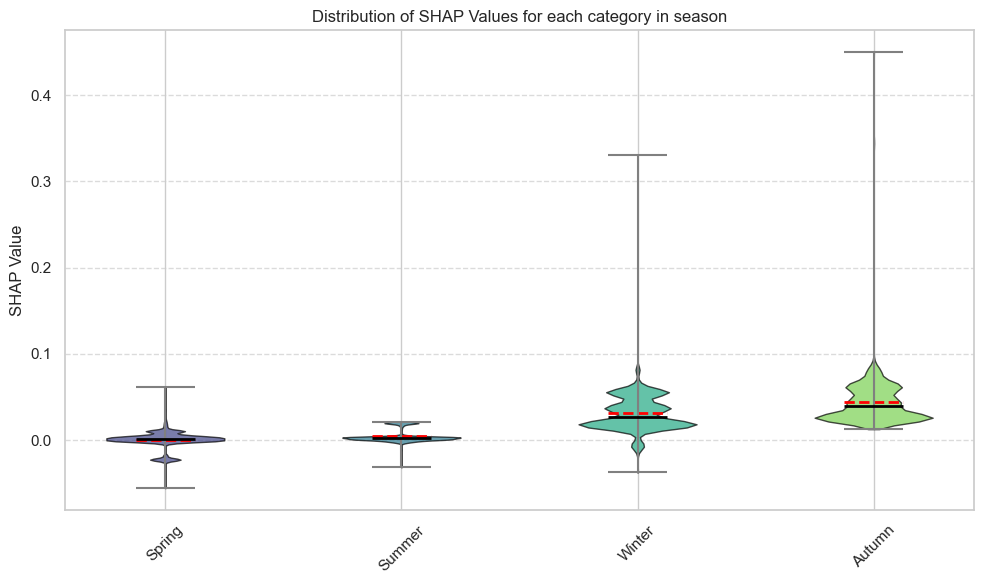

array([[-0.09896581, -0.08503218, -0.07707181, ...,  0.        ,
         0.        ,  0.00384353],
       [-0.10062547, -0.01707261,  0.06369945, ...,  0.        ,
         0.        ,  0.01882262],
       [ 0.35457516,  0.14872148,  0.09803488, ...,  0.        ,
         0.        ,  0.00305073],
       ...,
       [-0.01543085,  0.07812231,  0.00787403, ...,  0.        ,
         0.        ,  0.00240883],
       [ 0.00772173,  0.02067029, -0.05766888, ...,  0.        ,
         0.        , -0.01729834],
       [-0.12442263, -0.1236796 , -0.08794003, ...,  0.        ,
         0.        ,  0.00392374]])

In [15]:
shap_explain_model_on_batch(model, x, x.columns.tolist())

# Dump For App Building

In [16]:
from GeneralPurposeWebApp.generate_config import dump_config_from_df

In [17]:
model_save_path = './LGBMClassifier_model.txt'
model.booster_.save_model(model_save_path)

In [18]:
dump_config_from_df(df, "Term Deposit Subcription Prediction",'y',model_save_path,'config.json')

Configuration template saved to 'config.json'.
Please review and fill in 'model_type', 'model_path', and verify 'class_names' (if applicable).
